In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import seaborn as sns
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('all')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
import re
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_

In [71]:
df = pd.read_csv('data.csv', on_bad_lines='skip', index_col=0)
df.head()

,Text,Author
0,This study investigates the chemical compositi...,AI
1,This study explores the cultural history of oi...,AI
2,Isolation of human peripheral blood mononucle...,Human
3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,"Within volleyball, performance analysis is em...",Human


In [72]:
df.tail()

,Text,Author
6064,Computational models serve as useful compleme...,Human
6065,During transport and storage of drinking wate...,Human
6066,The parameter values of neural networks will ...,Human
6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,Human
6068,Generative AI for video is computationally exp...,AI


In [73]:
df.sample(5)

,Text,Author
786,"Aim: Physicians, like other healthcare profess...",Human
4623,AI for chemical reactions. We trained a Graph ...,AI
3316,A nutritious diet is essential for preventing...,Human
4525,Bionic eyes require high-resolution stimulatio...,AI
3412,Renal dysfunction in heart failure increases ...,Human


In [74]:
df.shape

(6069, 2)

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6069 entries, 0 to 6068
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Text    6069 non-null   str  
 1   Author  6069 non-null   str  
dtypes: str(2)
memory usage: 6.6 MB


In [76]:
df.describe(include='object')

C:\Users\acer\AppData\Local\Temp\ipykernel_7976\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Text,Author
count,6069,6069
unique,6069,2
top,This study investigates the chemical compositi...,AI
freq,1,3069


In [77]:
df.isnull().sum()

Text      0
Author    0
dtype: int64

In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
df = df.rename(columns={'Author':'target','Text':'Message'})
df

,Message,target
0,This study investigates the chemical compositi...,AI
1,This study explores the cultural history of oi...,AI
2,Isolation of human peripheral blood mononucle...,Human
3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,"Within volleyball, performance analysis is em...",Human
...,...,...
6064,Computational models serve as useful compleme...,Human
6065,During transport and storage of drinking wate...,Human
6066,The parameter values of neural networks will ...,Human
6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,Human


In [80]:
df['target'] = encoder.fit_transform(df['target'])
df

,Message,target
0,This study investigates the chemical compositi...,0
1,This study explores the cultural history of oi...,0
2,Isolation of human peripheral blood mononucle...,1
3,Dynamic Bayesian Networks (DBNs) are probabil...,1
4,"Within volleyball, performance analysis is em...",1
...,...,...
6064,Computational models serve as useful compleme...,1
6065,During transport and storage of drinking wate...,1
6066,The parameter values of neural networks will ...,1
6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,1


In [81]:
df['target'].value_counts()

target
0    3069
1    3000
Name: count, dtype: int64

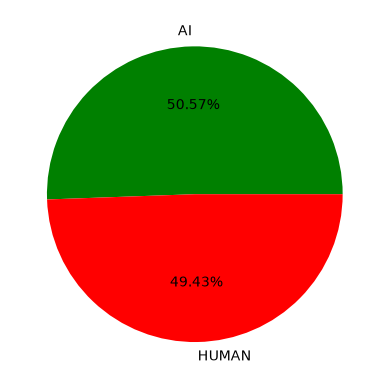

In [82]:
plt.pie(df['target'].value_counts(), labels=['AI','HUMAN'],autopct="%.2f%%",colors=['green','red'])
plt.show()

In [83]:
df['num_characters'] = df['Message'].apply(len)
df

,Message,target,num_characters
0,This study investigates the chemical compositi...,0,132
1,This study explores the cultural history of oi...,0,156
2,Isolation of human peripheral blood mononucle...,1,2262
3,Dynamic Bayesian Networks (DBNs) are probabil...,1,878
4,"Within volleyball, performance analysis is em...",1,1392
...,...,...,...
6064,Computational models serve as useful compleme...,1,1296
6065,During transport and storage of drinking wate...,1,1696
6066,The parameter values of neural networks will ...,1,1538
6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,1,1680


In [84]:
df['num_words'] = df['Message'].apply(lambda x : len(nltk.word_tokenize(x)))
df

,Message,target,num_characters,num_words
0,This study investigates the chemical compositi...,0,132,19
1,This study explores the cultural history of oi...,0,156,25
2,Isolation of human peripheral blood mononucle...,1,2262,449
3,Dynamic Bayesian Networks (DBNs) are probabil...,1,878,148
4,"Within volleyball, performance analysis is em...",1,1392,242
...,...,...,...,...
6064,Computational models serve as useful compleme...,1,1296,196
6065,During transport and storage of drinking wate...,1,1696,255
6066,The parameter values of neural networks will ...,1,1538,261
6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,1,1680,234


In [85]:
df['num_sentences'] = df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))
df

,Message,target,num_characters,num_words,num_sentences
0,This study investigates the chemical compositi...,0,132,19,1
1,This study explores the cultural history of oi...,0,156,25,1
2,Isolation of human peripheral blood mononucle...,1,2262,449,9
3,Dynamic Bayesian Networks (DBNs) are probabil...,1,878,148,5
4,"Within volleyball, performance analysis is em...",1,1392,242,9
...,...,...,...,...,...
6064,Computational models serve as useful compleme...,1,1296,196,10
6065,During transport and storage of drinking wate...,1,1696,255,10
6066,The parameter values of neural networks will ...,1,1538,261,6
6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,1,1680,234,8


In [86]:
# human
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,3000.000000,3000.000000,3000.000000
mean,1943.590667,316.580333,11.941333
std,612.266781,103.923248,4.327910
min,83.000000,12.000000,1.000000
25%,1552.000000,245.000000,9.000000
50%,1873.000000,310.000000,11.000000
75%,2214.000000,365.000000,14.000000
max,4901.000000,881.000000,33.000000


In [18]:
# ai
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,3069.000000,3069.000000,3069.000000
mean,313.435973,50.497882,2.974585
std,85.414674,14.594958,1.050240
min,51.000000,6.000000,1.000000
25%,292.000000,46.000000,3.000000
50%,332.000000,54.000000,3.000000
75%,365.000000,60.000000,4.000000
max,556.000000,99.000000,6.000000


In [87]:
df

,Message,target,num_characters,num_words,num_sentences
0,This study investigates the chemical compositi...,0,132,19,1
1,This study explores the cultural history of oi...,0,156,25,1
2,Isolation of human peripheral blood mononucle...,1,2262,449,9
3,Dynamic Bayesian Networks (DBNs) are probabil...,1,878,148,5
4,"Within volleyball, performance analysis is em...",1,1392,242,9
...,...,...,...,...,...
6064,Computational models serve as useful compleme...,1,1296,196,10
6065,During transport and storage of drinking wate...,1,1696,255,10
6066,The parameter values of neural networks will ...,1,1538,261,6
6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,1,1680,234,8


In [19]:
df.corr(numeric_only=True)

,target,num_characters,num_words,num_sentences
target,1.000000,0.882361,0.874492,0.819706
num_characters,0.882361,1.000000,0.992050,0.953378
num_words,0.874492,0.992050,1.000000,0.955227
num_sentences,0.819706,0.953378,0.955227,1.000000


<Axes: >

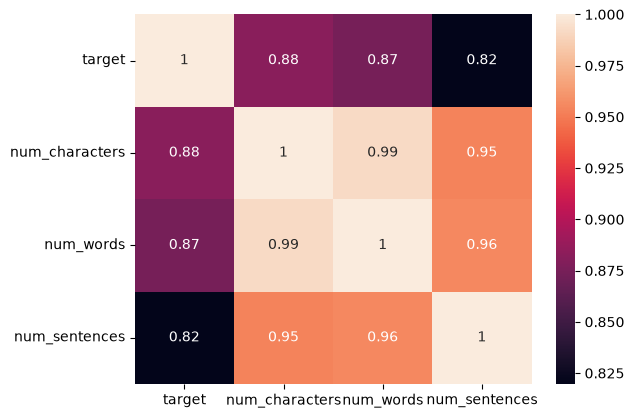

In [20]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

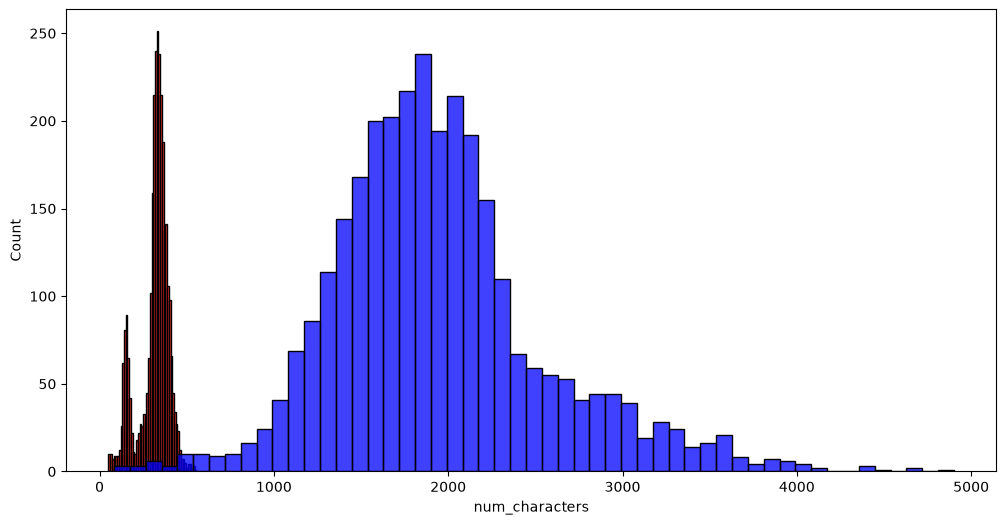

In [21]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'],color='red')
sns.histplot(df[df['target'] == 1]['num_characters'],color='blue')
plt.show()

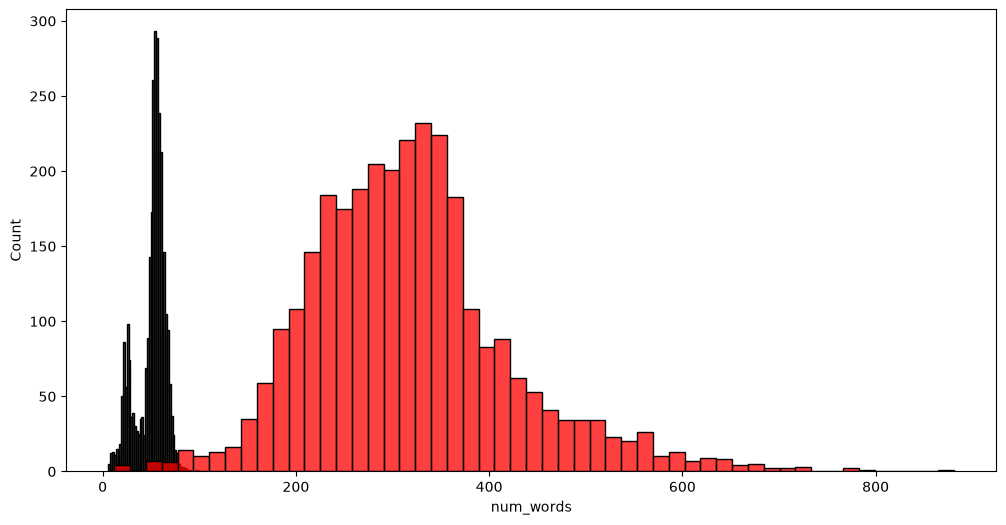

In [22]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'], color='black')
sns.histplot(df[df['target'] == 1]['num_words'],color='red')
plt.show()

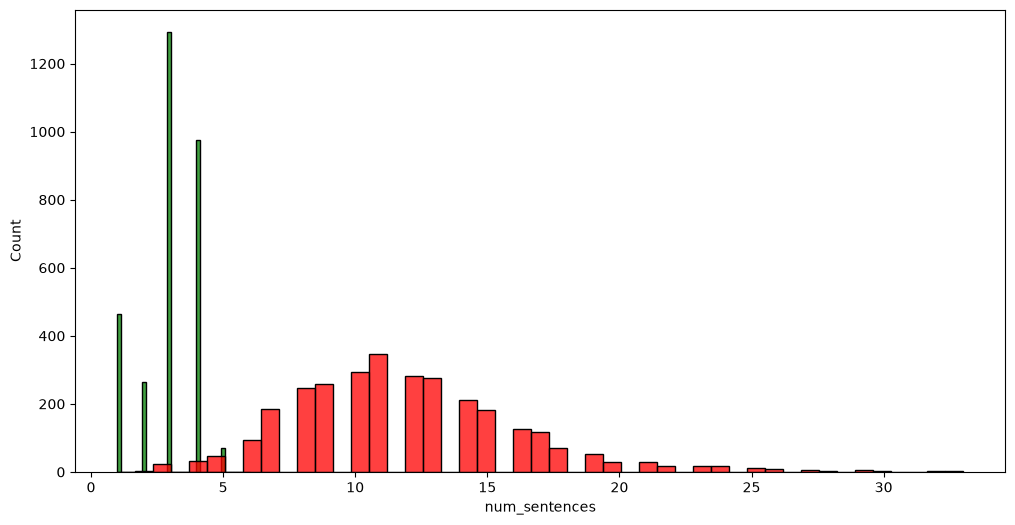

In [23]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_sentences'],color='green')
sns.histplot(df[df['target'] == 1]['num_sentences'],color='red')
plt.show()

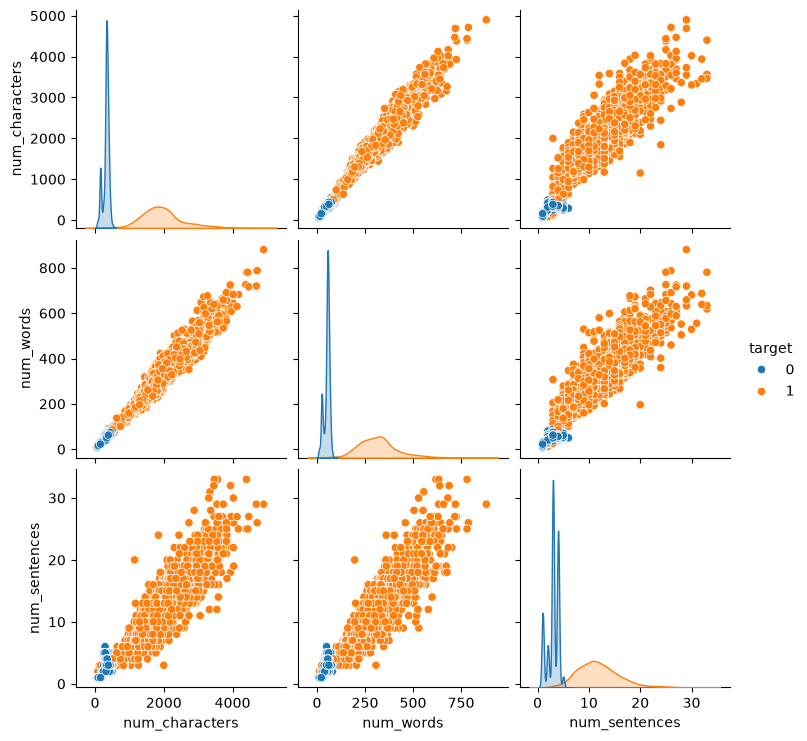

In [24]:
sns.pairplot(df,hue='target')
plt.show()

In [25]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:

# Initialize the PorterStemmer
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()  # Convert to lowercase
    text = nltk.word_tokenize(text)  # Tokenize the text make a list of words
    
    y = []  # Removing special characters
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:  # Remove stopwords and punctuation
        if i not in stopwords.words('english') or i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:  # Apply stemming
        y.append(ps.stem(i))
    
    return " ".join(y)

In [27]:
df['Message'][0]

'This study investigates the chemical composition of thermal springs in Afyonkarahisar, assessing their potential for health tourism.'

In [28]:
df['Message'][1]

'This study explores the cultural history of oil wrestling in Kırkpınar, analyzing its status as an intangible cultural heritage and its modern organization.'

In [29]:
df['transformed_text'] = df['Message'].apply(transform_text)

In [30]:
df

,Message,target,num_characters,num_words,num_sentences,transformed_text
0,This study investigates the chemical compositi...,0,132,19,1,studi investig chemic composit thermal spring ...
1,This study explores the cultural history of oi...,0,156,25,1,studi explor cultur histori oil wrestl kırkpın...
2,Isolation of human peripheral blood mononucle...,1,2262,449,9,isol human peripher blood mononuclear cell pbm...
3,Dynamic Bayesian Networks (DBNs) are probabil...,1,878,148,5,dynam bayesian network dbn probabilist model d...
4,"Within volleyball, performance analysis is em...",1,1392,242,9,within volleybal perform analysi employ identi...
...,...,...,...,...,...,...
6064,Computational models serve as useful compleme...,1,1296,196,10,comput model serv use complement physic experi...
6065,During transport and storage of drinking wate...,1,1696,255,10,transport storag drink water microbi water qua...
6066,The parameter values of neural networks will ...,1,1538,261,6,paramet valu neural network directli affect pe...
6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,1,1680,234,8,crumb rubber modifi asphalt crma offer vital p...


In [89]:
"studi investing ... " + " " + " studi explor cultur ..." + " " + " isol human ... "

'studi investing ...   studi explor cultur ...  isol human ... '

In [31]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

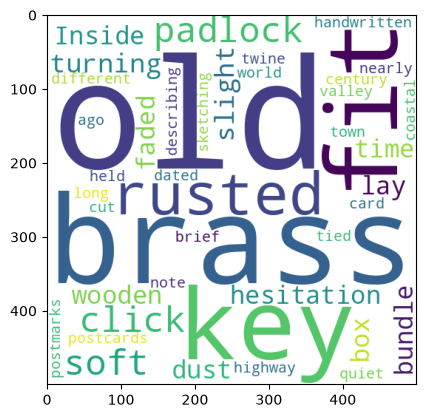

In [94]:
wc_text = "The old brass key fit into the rusted padlock with a soft click, turning after a slight hesitation of time and dust. Inside the wooden box lay a bundle of faded postcards tied with twine, their postmarks dated nearly a century ago. Each card held a brief, handwritten note describing a different coastal town, sketching a quiet world long before the highway cut through the valley."
plt.imshow(wc.generate(wc_text))


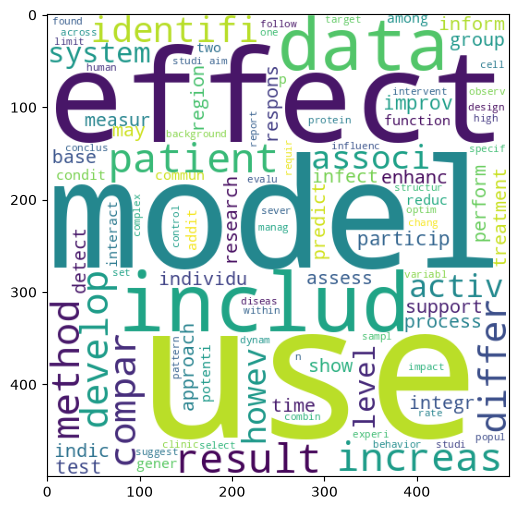

In [ ]:
human_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(human_wc)

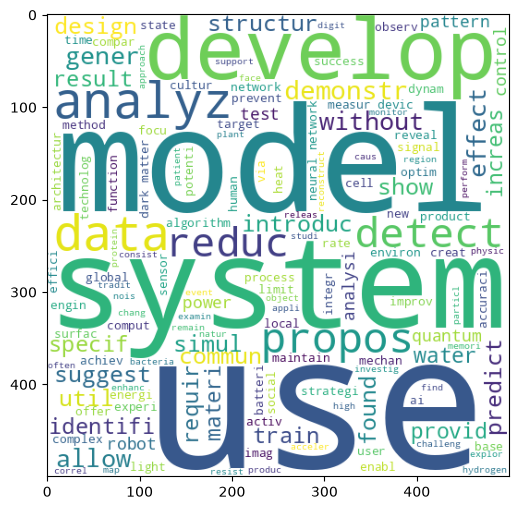

In [33]:
ai_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ai_wc)

In [34]:
human_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        human_corpus.append(word)

In [35]:
human_corpus

['isol',
 'human',
 'peripher',
 'blood',
 'mononuclear',
 'cell',
 'pbmc',
 'blood',
 'typic',
 'involv',
 'densiti',
 'gradient',
 'medium',
 'densiti',
 'centrifug',
 'problem',
 'increas',
 'red',
 'blood',
 'cell',
 'rbc',
 'granulocyt',
 'gra',
 'contamin',
 'pbmc',
 'isol',
 'elaps',
 'time',
 'blood',
 'collect',
 'increas',
 'remain',
 'unresolv',
 'countermeasur',
 'rbc',
 'contamin',
 'hemolysi',
 'treatment',
 'avail',
 'howev',
 'extra',
 'step',
 'labori',
 'could',
 'introduc',
 'artifact',
 'overcom',
 'challeng',
 'develop',
 'novel',
 'isol',
 'devic',
 'featur',
 'proprietari',
 'insert',
 'structur',
 'design',
 'prevent',
 'rbc',
 'gra',
 'contamin',
 'pbmc',
 'isol',
 'blood',
 'efficaci',
 'method',
 'evalu',
 'isol',
 'pbmc',
 'donor',
 'analyz',
 'immun',
 'cell',
 'popul',
 'flow',
 'cytometri',
 'compar',
 'sepmat',
 'median',
 'q50',
 'interquartil',
 'rang',
 'iqr',
 'p',
 'lymphoprep',
 'method',
 'q50',
 'iqr',
 'p',
 'achiev',
 'significantli',
 'greater

In [36]:
ai_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ai_corpus.append(word)

In [37]:
ai_corpus

['studi',
 'investig',
 'chemic',
 'composit',
 'thermal',
 'spring',
 'afyonkarahisar',
 'assess',
 'potenti',
 'health',
 'tourism',
 'studi',
 'explor',
 'cultur',
 'histori',
 'oil',
 'wrestl',
 'kırkpınar',
 'analyz',
 'statu',
 'intang',
 'cultur',
 'heritag',
 'modern',
 'organ',
 'research',
 'analyz',
 'mughal',
 'miniatur',
 'paint',
 'synthes',
 'persian',
 'indian',
 'european',
 'visual',
 'tradit',
 'centuri',
 'detail',
 'formal',
 'analysi',
 'specif',
 'manuscript',
 'demonstr',
 'artist',
 'hybrid',
 'serv',
 'imperi',
 'diplomaci',
 'studi',
 'examin',
 'dialectolog',
 'black',
 'sea',
 'region',
 'focus',
 'phonet',
 'characterist',
 'distinguish',
 'standard',
 'turkish',
 'understand',
 'dream',
 'format',
 'scientif',
 'difficult',
 'use',
 'eeg',
 'natur',
 'languag',
 'process',
 'decod',
 'visual',
 'content',
 'dream',
 'rem',
 'sleep',
 'train',
 'decod',
 'wake',
 'visual',
 'imageri',
 'reconstruct',
 'rough',
 'video',
 'approxim',
 'dream',
 'content',
 

In [38]:
from collections import Counter
ai_corpus = Counter(ai_corpus)
ai_corpus

Counter({'use': 987,
         'model': 824,
         'system': 492,
         'analyz': 464,
         'data': 392,
         'develop': 379,
         'quantum': 344,
         'network': 340,
         'show': 316,
         'energi': 311,
         'detect': 300,
         'reduc': 292,
         'analysi': 287,
         'propos': 280,
         'gener': 273,
         'studi': 271,
         'demonstr': 264,
         'learn': 262,
         'predict': 258,
         'investig': 249,
         'simul': 249,
         'without': 247,
         'effect': 243,
         'examin': 236,
         'suggest': 231,
         'allow': 223,
         'result': 220,
         'train': 216,
         'cell': 216,
         'power': 201,
         'research': 197,
         'robot': 197,
         'time': 187,
         'water': 185,
         'structur': 182,
         'identifi': 180,
         'econom': 177,
         'design': 177,
         'comput': 175,
         'util': 172,
         'introduc': 170,
         'provid': 16

In [39]:
human_corpus = Counter(human_corpus)
human_corpus

Counter({'studi': 5027,
         'use': 4483,
         'model': 3134,
         'result': 2430,
         'data': 2296,
         'health': 2283,
         'effect': 2192,
         'method': 2031,
         'patient': 2014,
         'analysi': 1920,
         'associ': 1881,
         'includ': 1793,
         'identifi': 1614,
         'find': 1586,
         'group': 1577,
         'increas': 1557,
         'differ': 1526,
         'p': 1481,
         'assess': 1459,
         'develop': 1445,
         'risk': 1444,
         'factor': 1436,
         'signific': 1429,
         'among': 1421,
         'improv': 1400,
         'show': 1391,
         '95': 1358,
         'provid': 1335,
         'compar': 1332,
         'diseas': 1332,
         'cell': 1309,
         'ci': 1273,
         'system': 1261,
         'level': 1261,
         'perform': 1254,
         'particip': 1239,
         'research': 1215,
         'age': 1195,
         'activ': 1163,
         'test': 1148,
         'potenti': 1130

In [40]:
most_common_human_words = pd.DataFrame(Counter(human_corpus).most_common(30), columns=['Word', 'Frequency'])
most_common_human_words

,Word,Frequency
0,studi,5027
1,use,4483
2,model,3134
3,result,2430
4,data,2296
5,health,2283
6,effect,2192
7,method,2031
8,patient,2014
9,analysi,1920


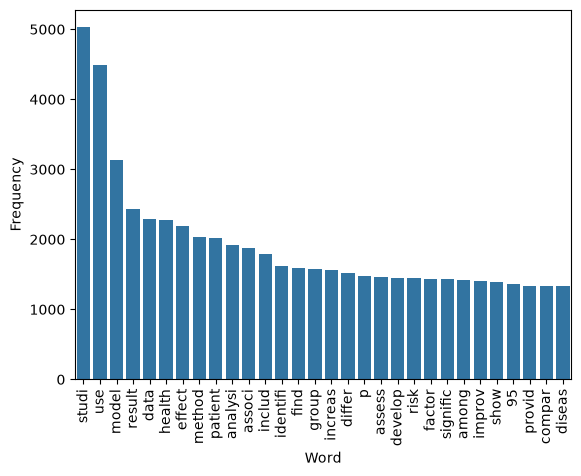

In [41]:
# Plot the barplot
sns.barplot(x='Word', y='Frequency', data=most_common_human_words)
plt.xticks(rotation='vertical')
plt.show()

In [42]:
most_common_ai_words = pd.DataFrame(Counter(ai_corpus).most_common(30), columns=['Word', 'Frequency'])
most_common_ai_words

,Word,Frequency
0,use,987
1,model,824
2,system,492
3,analyz,464
4,data,392
5,develop,379
6,quantum,344
7,network,340
8,show,316
9,energi,311


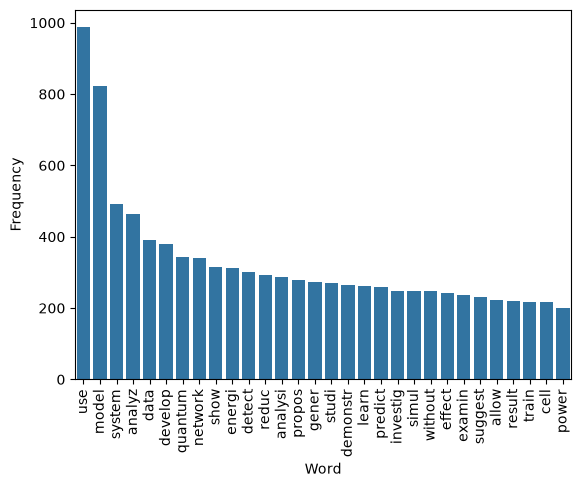

In [43]:
# Plot the barplot
sns.barplot(x='Word', y='Frequency', data=most_common_ai_words)
plt.xticks(rotation='vertical')
plt.show()

In [44]:
df = df[['transformed_text','target']]
df

,transformed_text,target
0,studi investig chemic composit thermal spring ...,0
1,studi explor cultur histori oil wrestl kırkpın...,0
2,isol human peripher blood mononuclear cell pbm...,1
3,dynam bayesian network dbn probabilist model d...,1
4,within volleybal perform analysi employ identi...,1
...,...,...
6064,comput model serv use complement physic experi...,1
6065,transport storag drink water microbi water qua...,1
6066,paramet valu neural network directli affect pe...,1
6067,crumb rubber modifi asphalt crma offer vital p...,1


In [45]:
df.to_csv('cleaned_data.csv', index=False)

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)

In [47]:
df['transformed_text']

0       studi investig chemic composit thermal spring ...
1       studi explor cultur histori oil wrestl kırkpın...
2       isol human peripher blood mononuclear cell pbm...
3       dynam bayesian network dbn probabilist model d...
4       within volleybal perform analysi employ identi...
                              ...                        
6064    comput model serv use complement physic experi...
6065    transport storag drink water microbi water qua...
6066    paramet valu neural network directli affect pe...
6067    crumb rubber modifi asphalt crma offer vital p...
6068    gener ai video comput expens introduc latent d...
Name: transformed_text, Length: 6069, dtype: str

In [48]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6069, 3000))

In [49]:
y = df['target'].values
y

array([0, 0, 1, ..., 1, 1, 0], shape=(6069,))

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [51]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9217462932454695
[[551  63]
 [ 32 568]]
0.9001584786053882


In [52]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9118616144975288
[[556  58]
 [ 49 551]]
0.9047619047619048


In [53]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9892915980230642
[[614   0]
 [ 13 587]]
1.0


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [55]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [56]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [57]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [58]:
train_classifier(lrc,X_train,y_train,X_test,y_test)

c:\Users\acer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\acer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


(0.9505766062602965, 0.9607508532423208)

In [59]:
clfs.items()

dict_items([('SVC', SVC(gamma=1.0, kernel='sigmoid')), ('KN', KNeighborsClassifier()), ('NB', MultinomialNB()), ('DT', DecisionTreeClassifier(max_depth=5)), ('LR', LogisticRegression(penalty='l1', solver='liblinear')), ('RF', RandomForestClassifier(n_estimators=50, random_state=2)), ('AdaBoost', AdaBoostClassifier(random_state=2)), ('BgC', BaggingClassifier(n_estimators=50, random_state=2)), ('ETC', ExtraTreesClassifier(n_estimators=50, random_state=2)), ('GBDT', GradientBoostingClassifier(n_estimators=50, random_state=2)), ('xgb', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_c

In [60]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9761120263591433
Precision -  0.9830795262267343
For  KN
Accuracy -  0.8904448105436573
Precision -  0.893760539629005
For  NB
Accuracy -  0.9118616144975288
Precision -  0.9047619047619048
For  DT
Accuracy -  0.9349258649093904
Precision -  0.9468267581475128
For  LR
Accuracy -  0.9505766062602965
Precision -  0.9607508532423208


c:\Users\acer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\acer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9909390444810544
Precision -  1.0
For  AdaBoost
Accuracy -  0.9612850082372323
Precision -  0.9825479930191972
For  BgC
Accuracy -  0.9728171334431631
Precision -  0.9748743718592965
For  ETC
Accuracy -  0.9942339373970346
Precision -  0.994991652754591
For  GBDT
Accuracy -  0.9719934102141681
Precision -  0.9812925170068028
For  xgb
Accuracy -  0.9892915980230642
Precision -  0.9949409780775716


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Accuracy',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
5,RF,0.990939,1.000000
8,ETC,0.994234,0.994992
10,xgb,0.989292,0.994941
0,SVC,0.976112,0.983080
6,AdaBoost,0.961285,0.982548
9,GBDT,0.971993,0.981293
7,BgC,0.972817,0.974874
4,LR,0.950577,0.960751
3,DT,0.934926,0.946827
2,NB,0.911862,0.904762


In [62]:
performance_df['Accuracy'].max(), performance_df['Precision'].max()

(0.9942339373970346, 1.0)

In [63]:
print(performance_df[performance_df['Accuracy'] == performance_df['Accuracy'].max()])
print()
print(performance_df[performance_df['Precision'] == performance_df['Precision'].max()])


  Algorithm  Accuracy  Precision
8       ETC  0.994234   0.994992

  Algorithm  Accuracy  Precision
5        RF  0.990939        1.0


In [65]:
from sklearn.model_selection import GridSearchCV

bnb_params = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'binarize': [0.0, 0.5, 1.0, None],
    'fit_prior': [True, False]
}

bnb_grid = GridSearchCV(
    BernoulliNB(),
    bnb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

bnb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BernoulliNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 0.5, ...], 'binarize': [0.0, 0.5, ...], 'fit_prior': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to se

In [66]:
bnb_grid.best_params_

{'alpha': 0.1, 'binarize': 0.0, 'fit_prior': True}

In [67]:
bnb = BernoulliNB(alpha=0.1, binarize=0.0, fit_prior=True)
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9892915980230642
[[614   0]
 [ 13 587]]
1.0
